In [1]:
pip install opendatasets

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import opendatasets as od
import warnings
warnings.filterwarnings("ignore")

In [4]:
data = od.download("https://www.kaggle.com/datasets/shree0910/ai-and-data-science-job-market-dataset-20202026/code")
data

Skipping, found downloaded files in "./ai-and-data-science-job-market-dataset-20202026" (use force=True to force download)


In [5]:
Data = pd.read_csv("/content/ai-and-data-science-job-market-dataset-20202026/AI Job Market Dataset.csv")
Data.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [6]:
Data.shape

(10345, 19)

In [7]:
Data.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='object')

In [8]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [9]:
missing = Data.isnull().sum()
missing

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


In [10]:
duplicates=Data.duplicated().sum()
duplicates

np.int64(0)

In [129]:
Data.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [11]:
statics1=Data.describe(include="O")
statics1

,job_title,company_size,company_industry,country,remote_type,experience_level,education_level,hiring_urgency
count,10345,10345,10345,10345,10345,10345,10345,10345
unique,6,4,6,7,3,3,3,3
top,Business Analyst,Startup,Technology,Germany,Remote,Entry,Master,High
freq,1773,2656,1787,1498,3513,3513,3529,5195


In [12]:
Data["salary"]=Data["salary"].replace('[\$,]', '', regex=True).astype(float)
Data["salary"].head()

,salary
0,158322.0
1,163666.0
2,158556.0
3,95775.0
4,111873.0


In [50]:
Categorical = Data.select_dtypes(include="object")
Categorical.head()

,job_title,company_size,company_industry,country,remote_type,experience_level,education_level,hiring_urgency
0,AI Engineer,Startup,Retail,Canada,Remote,Senior,Master,Low
1,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,Bachelor,High
2,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,Master,High
3,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,Master,High
4,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,Master,Low


In [14]:
numeric=Data.select_dtypes(include=["number"]).drop("job_id",axis=1)
numeric.head()

,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
0,2,0,0,0,1,0,158322.0,6,2024,4
1,0,1,1,1,0,1,163666.0,11,2026,9
2,14,1,0,1,0,1,158556.0,3,2026,9
3,9,0,1,0,1,1,95775.0,3,2025,7
4,5,1,1,1,0,0,111873.0,12,2021,2


In [15]:
Data.drop("job_id",inplace=True,axis=1)

In [16]:
skill_cols = ['skills_python','skills_sql','skills_ml','skills_deep_learning','skills_cloud']

Data["total_skills"] = Data[skill_cols].sum(axis=1)

In [17]:
Data["date"] = pd.to_datetime(Data["job_posting_year"].astype(str) + "-" +
                              Data["job_posting_month"].astype(str))

In [18]:
Data.head(10)

,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings,total_skills,date
0,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322.0,6,2024,Low,4,1,2024-06-01
1,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666.0,11,2026,High,9,4,2026-11-01
2,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556.0,3,2026,High,9,3,2026-03-01
3,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775.0,3,2025,High,7,3,2025-03-01
4,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873.0,12,2021,Low,2,3,2021-12-01
5,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6,Master,1,0,1,1,0,165878.0,5,2021,High,2,3,2021-05-01
6,Data Scientist,MNC,Technology,Germany,Remote,Entry,14,Bachelor,0,0,0,0,0,67027.0,8,2026,High,8,0,2026-08-01
7,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4,PhD,1,0,1,0,1,78392.0,8,2023,High,7,3,2023-08-01
8,Machine Learning Engineer,Startup,Education,Canada,Onsite,Mid,2,PhD,0,0,0,0,1,123840.0,5,2021,Low,3,1,2021-05-01
9,Data Engineer,Enterprise,Retail,USA,Onsite,Senior,9,Master,1,0,0,0,1,112408.0,4,2024,High,7,2,2024-04-01


,count
job_title,
Business Analyst,1773
AI Engineer,1742
Machine Learning Engineer,1740
Data Analyst,1711
Data Scientist,1703
Data Engineer,1676


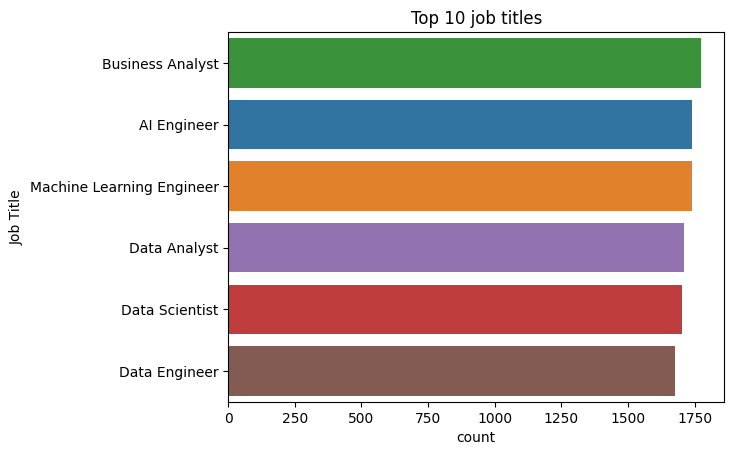

In [19]:
display(Data["job_title"].value_counts())
sns.countplot(y="job_title",data=Data,order=Data["job_title"].value_counts().index[:10],hue="job_title")
plt.title("Top 10 job titles")
plt.xlabel("count")
plt.ylabel("Job Title")
plt.show()

In [162]:
# for columns in Categorical.columns:
#   display(f"--{columns}--")
#   display(Categorical[columns].value_counts())

In [20]:
Data.groupby("job_title")["salary"].mean().sort_values(ascending=False)

,salary
job_title,
AI Engineer,139945.210677
Machine Learning Engineer,139705.422989
Business Analyst,101642.028765
Data Engineer,99711.085322
Data Scientist,99645.837933
Data Analyst,99136.475745


In [154]:
# for columns in numeric.columns:
#   display(f"--{columns}--")
#   display(numeric[columns].value_counts().head(10))

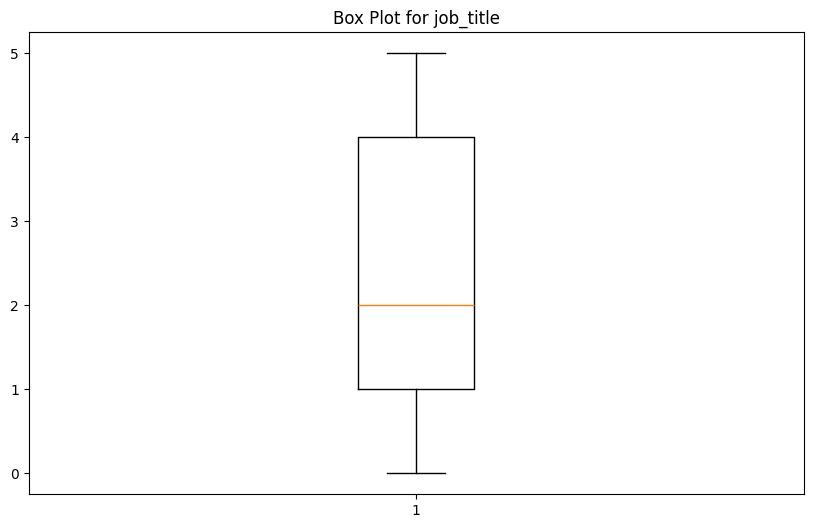

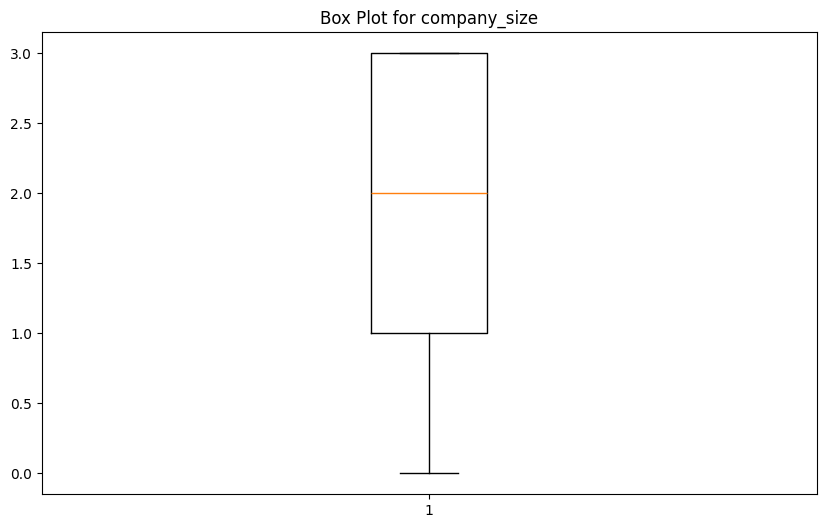

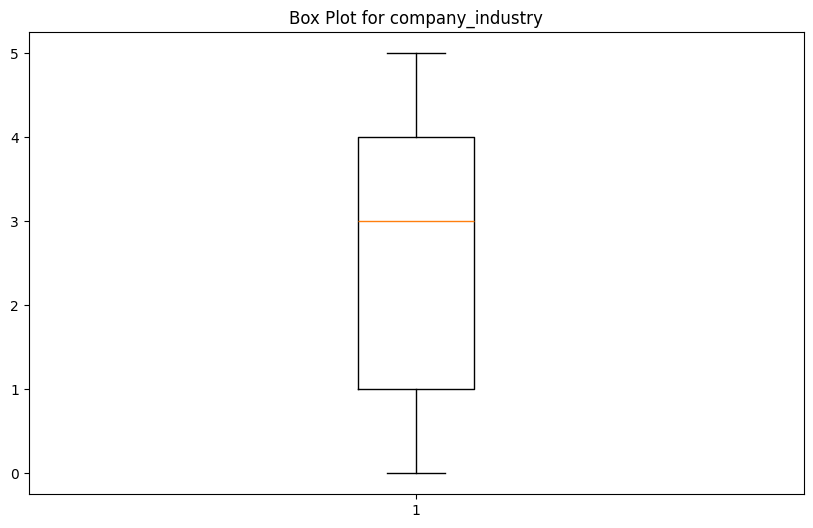

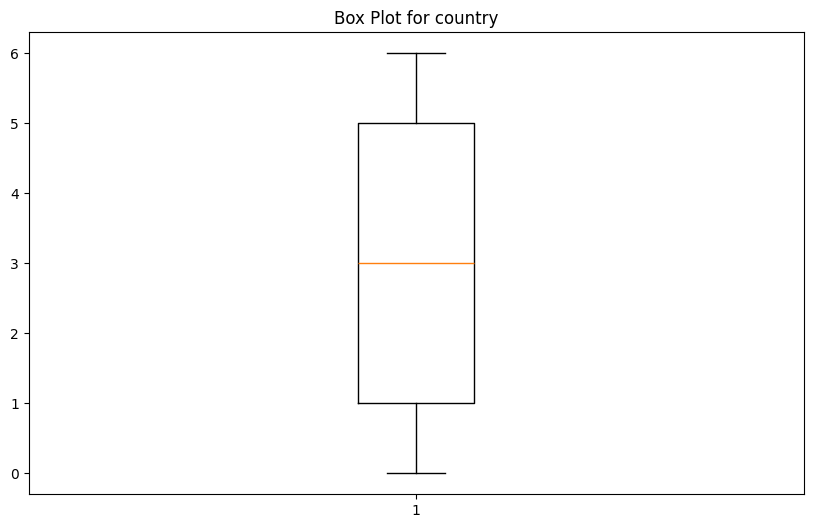

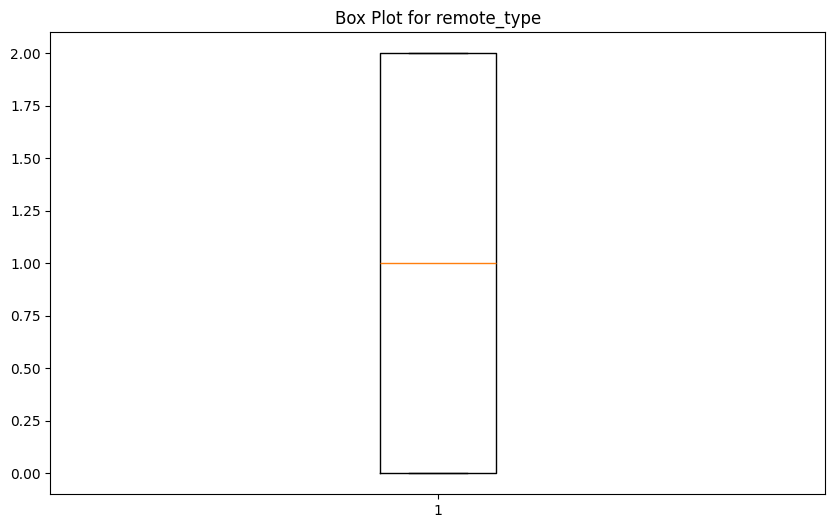

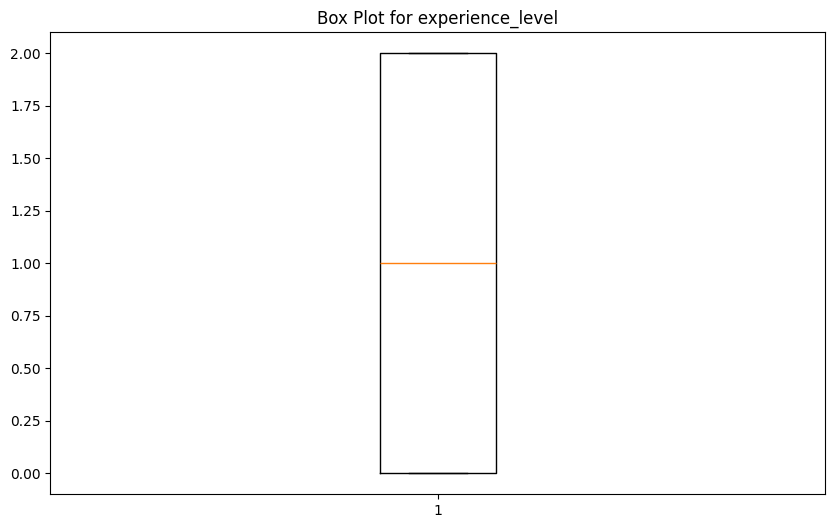

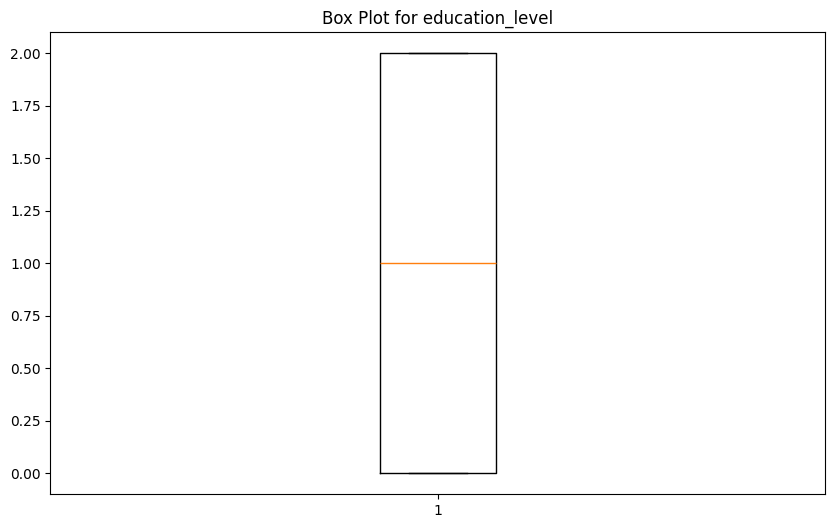

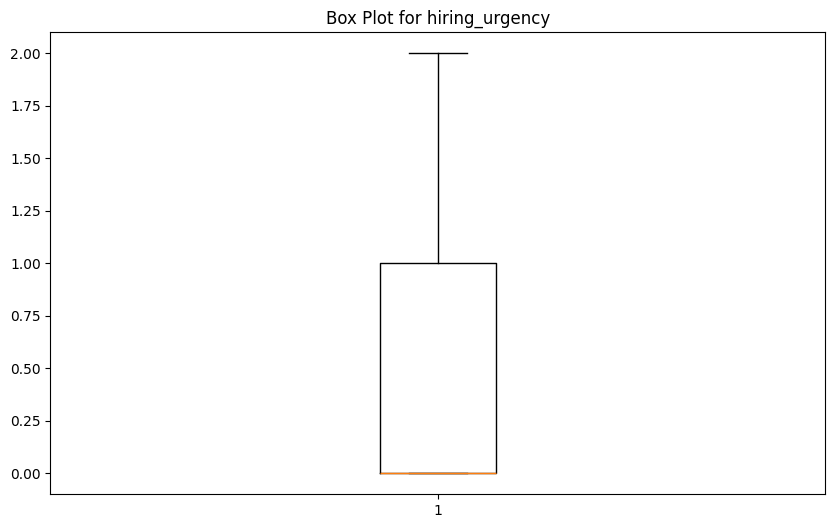

In [21]:
for c in Categorical.columns:
  encode=Categorical[c].astype("category").cat.codes
  Categorical[c]=encode
  fig, ax = plt.subplots(figsize=(10,6))
  ax.boxplot(Categorical[c])
  ax.set_title(f"Box Plot for {c}")
  plt.show()

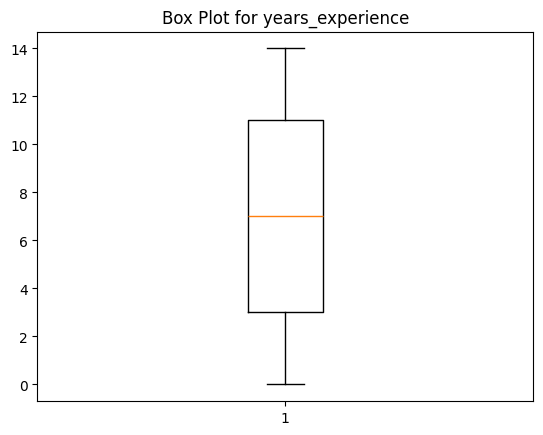

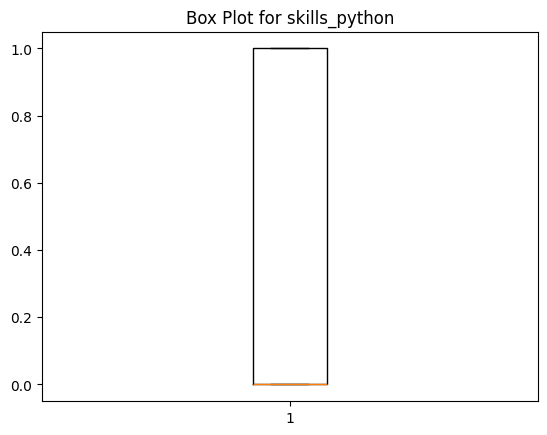

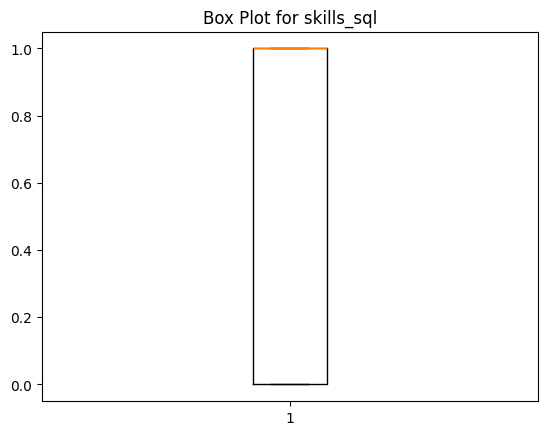

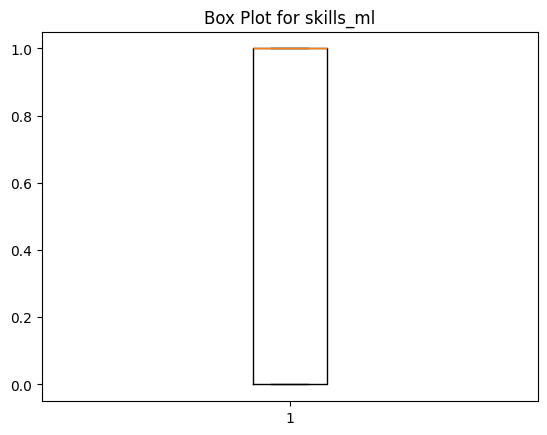

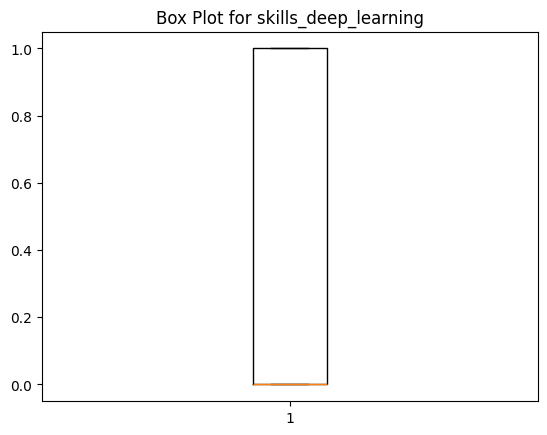

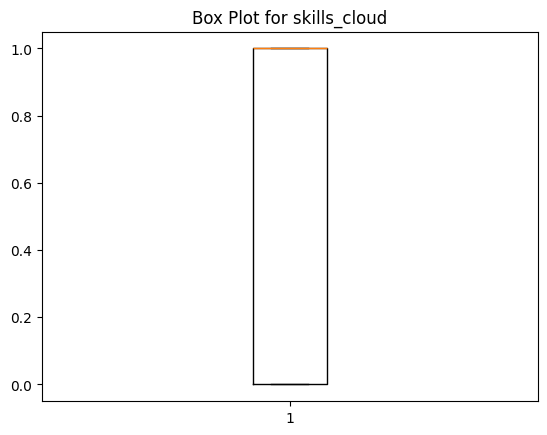

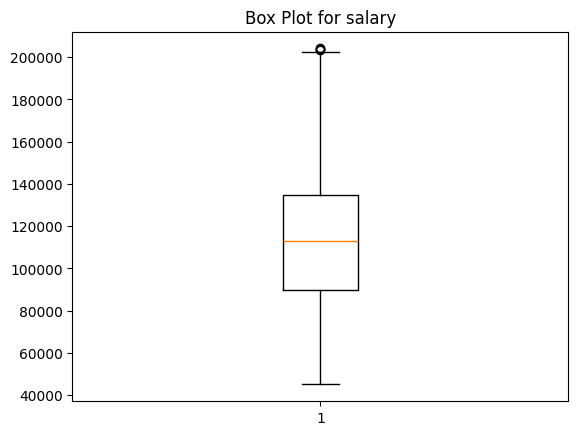

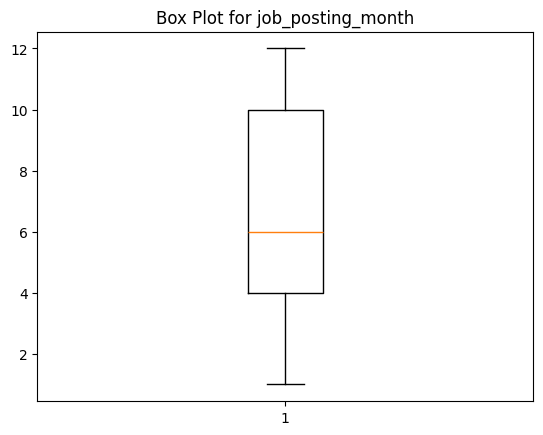

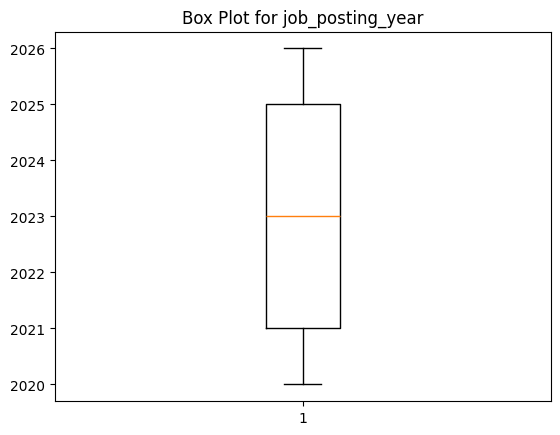

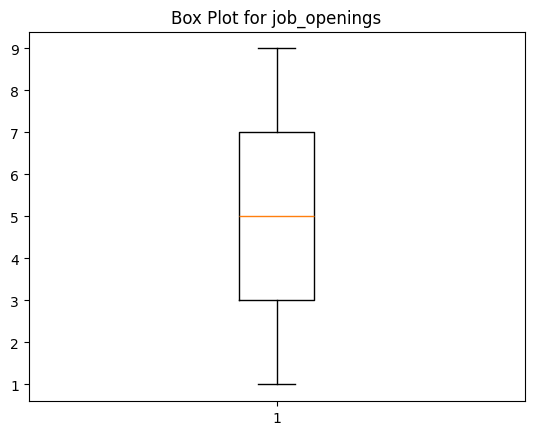

In [22]:
for columns in numeric.columns:
  plt.boxplot(numeric[columns])
  plt.title("Box Plot for {}".format(columns))
  plt.show()

In [23]:
Q1 = np.quantile(Data["salary"], 0.25)
Q3 = np.quantile(Data["salary"], 0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
Data = Data[(Data["salary"] >= lower_bound) & (Data["salary"] <= upper_bound)]

<Axes: xlabel='salary'>

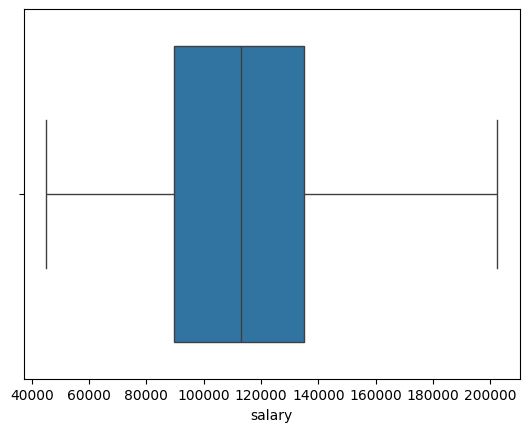

In [ ]:
sns.boxplot(x=Data["salary"])

In [24]:
print("Before:", len(numeric))
print("After:", len(Data))

Before: 10345
After: 10341


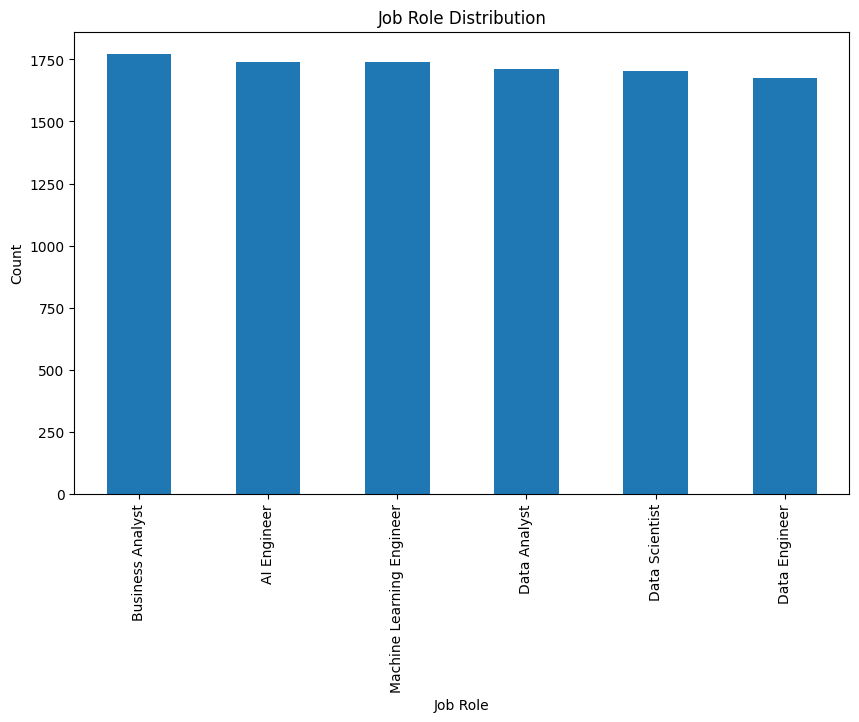

In [25]:
# job role distribution
Data["job_title"].value_counts().head(10).plot(kind="bar",figsize=(10,6), )
plt.title("Job Role Distribution")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()

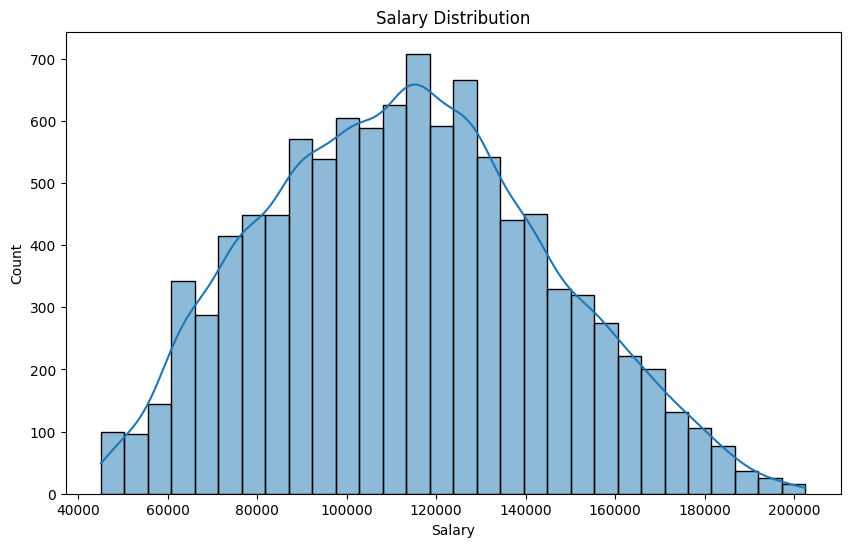

In [26]:
# Salary distribution
plt.figure(figsize=(10, 6))
sns.histplot(Data["salary"], bins=30, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

,salary
job_title,
AI Engineer,139945.21
Machine Learning Engineer,139705.42
Business Analyst,101642.03
Data Engineer,99711.09
Data Scientist,99645.84
Data Analyst,99136.48


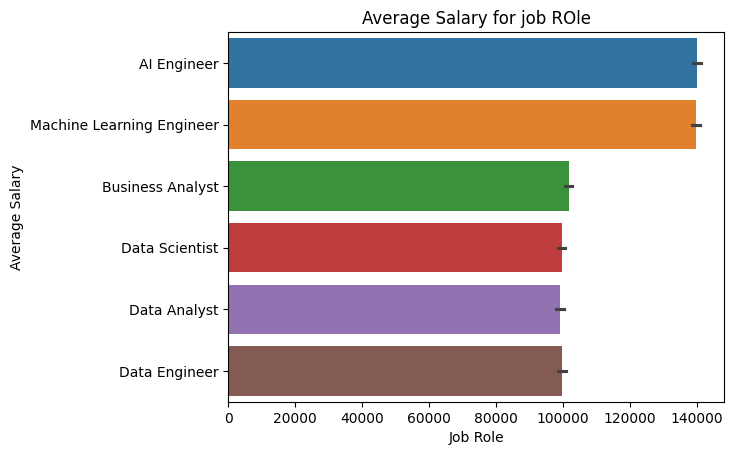

In [159]:
# salary by job
Salary_role=Data.groupby("job_title")["salary"].mean().round(2).sort_values(ascending=False)
display(Salary_role.head(10))
sns.barplot(x="salary", y="job_title", data=Data,hue="job_title")
plt.title("Average Salary for job ROle")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")
plt.show()


,salary
experience_level,
Senior,138212.44
Mid,113592.02
Entry,89095.87


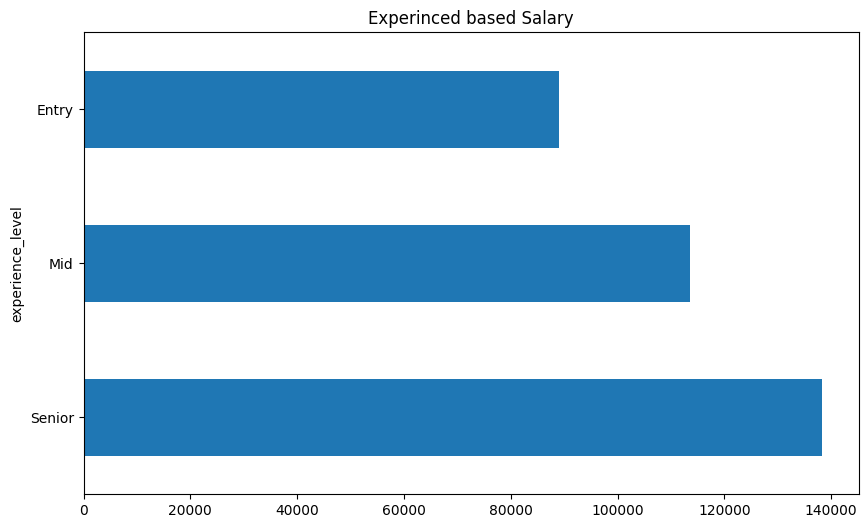

In [27]:
#Experience Level Analysis
Experince=Data.groupby("experience_level")["salary"].mean().round(2).sort_values(ascending=False)
display(Experince)
Experince.head(10).plot(kind="barh",figsize=(10,6))
plt.title("Experinced based Salary")
plt.show()


In [28]:
Data.groupby("job_posting_year")["job_openings"].sum()

,job_openings
job_posting_year,
2020,7378
2021,7473
2022,7464
2023,7344
2024,7316
2025,7448
2026,7331


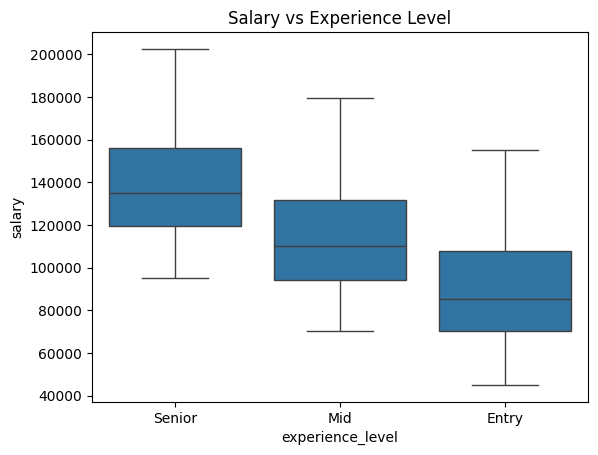

In [29]:
sns.boxplot(x="experience_level", y="salary", data=Data)
plt.title("Salary vs Experience Level")
plt.show()

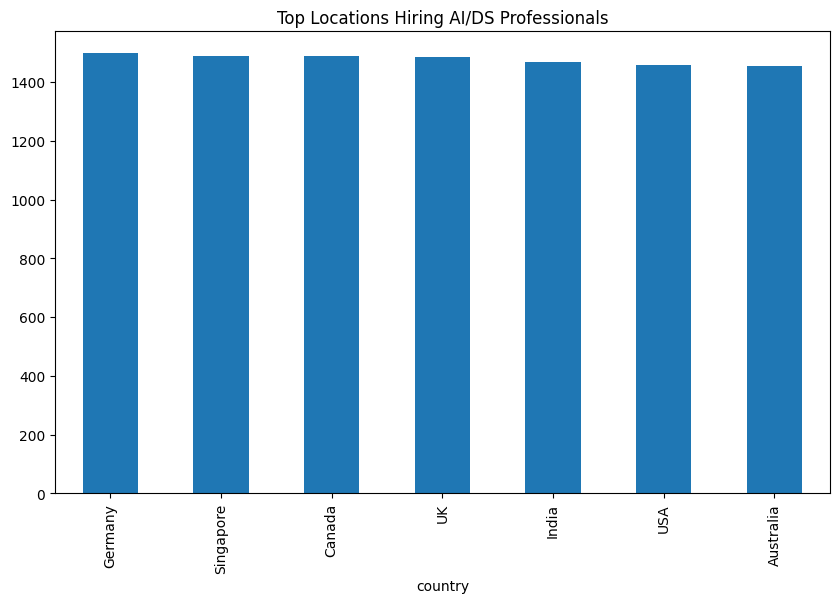

In [30]:
# lOCATION BASED JOB DEMAND
plt.figure(figsize=(10,6))
Data['country'].value_counts().head(10).plot(kind="bar")
plt.title("Top Locations Hiring AI/DS Professionals")
plt.show()

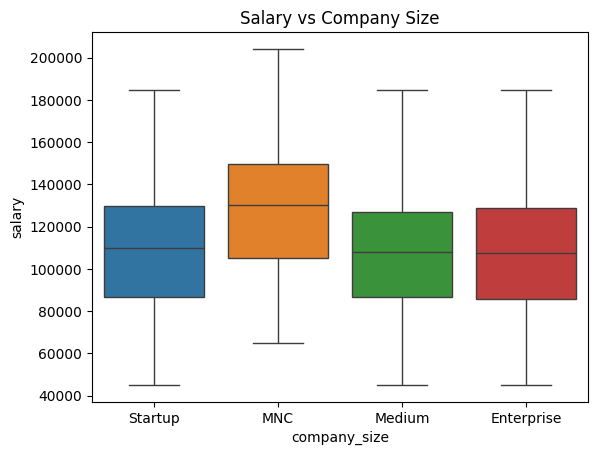

In [163]:
sns.boxplot(x="company_size", y="salary", data=Data,hue="company_size")
plt.title("Salary vs Company Size")
plt.show() #Large companies may pay higher salaries.

In [183]:
Data.columns

Index(['job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings', 'total_skills',
       'date'],
      dtype='object')

In [185]:
skill_cols = ['skills_python','skills_sql','skills_ml','skills_deep_learning','skills_cloud']

Data[skill_cols].sum().sort_values(ascending=False)

,0
skills_cloud,5291
skills_ml,5254
skills_sql,5204
skills_deep_learning,5152
skills_python,5101


<Axes: ylabel='job_title'>

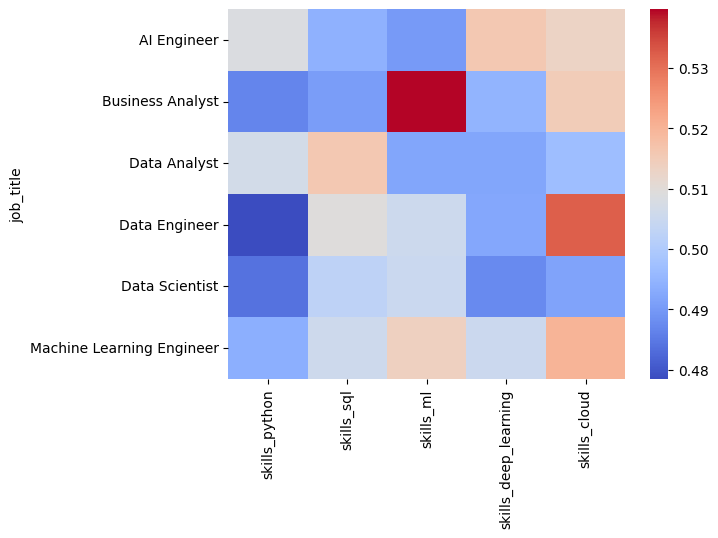

In [191]:
sns.heatmap(Data.groupby("job_title")[skill_cols].mean(), cmap="coolwarm")

In [38]:
#Modelling
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [39]:
target=Data["salary"]
feature=Data[['skills_python','skills_sql','skills_ml','skills_deep_learning','skills_cloud','years_experience','salary']]

In [33]:
Scaler=StandardScaler()
X_scaled=Scaler.fit_transform(feature)
Kmeans=KMeans(n_clusters=5,random_state=42)
Kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [34]:
Data["Cluster"]=Kmeans.fit_predict(X_scaled)

In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

Data['PCA1'] = X_pca[:,0]
Data['PCA2'] = X_pca[:,1]

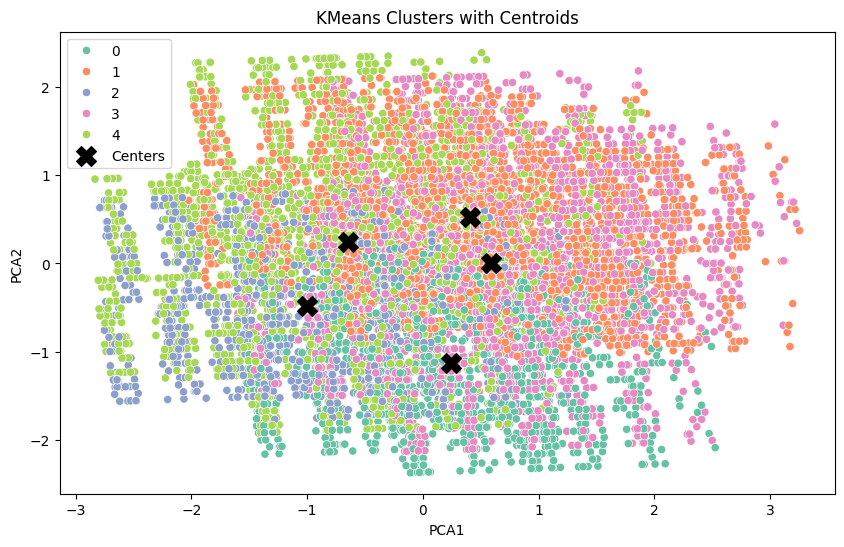

In [36]:
centers = pca.transform(Kmeans.cluster_centers_)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=Data['PCA1'],
    y=Data['PCA2'],
    hue=Data['Cluster'],
    palette='Set2'
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='black',
    s=200,
    marker='X',
    label='Centers'
)

plt.legend()
plt.title("KMeans Clusters with Centroids")
plt.show()

In [37]:
import plotly.express as px

fig = px.scatter(
    Data,
    x='PCA1',
    y='PCA2',
    color='Cluster',
    title="AI Job Market Clusters"
)

fig.show()

In [63]:
from sklearn.linear_model import LinearRegression
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error

In [71]:
X = Data.drop(columns=["salary","date",	"Cluster","PCA1","PCA2"])
y = Data["salary"]

In [75]:
Categorical_features=Categorical
Categorical_features.shape

(10341, 8)

In [76]:
numerical_features=numeric.drop("salary",axis=1)
numerical_features.shape


(10345, 9)

In [77]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), Categorical_features)
    ])

In [78]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [84]:
X.columns

Index(['job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings', 'total_skills'],
      dtype='object')

In [86]:
Data.columns.to_list()

['job_title',
 'company_size',
 'company_industry',
 'country',
 'remote_type',
 'experience_level',
 'years_experience',
 'education_level',
 'skills_python',
 'skills_sql',
 'skills_ml',
 'skills_deep_learning',
 'skills_cloud',
 'salary',
 'job_posting_month',
 'job_posting_year',
 'hiring_urgency',
 'job_openings',
 'total_skills',
 'date',
 'Cluster',
 'PCA1',
 'PCA2']

In [85]:
results = []
for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

ValueError: No valid specification of the columns. Only a scalar, list or slice of all integers or all strings, or boolean mask is allowed